Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**


**Circles Classification Assessment**

---

### **Import Libraries**

In [39]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools

from sklearn.datasets import make_circles
from sklearn.metrics import confusion_matrix


print(f'Tensorflow: {tf.__version__}\n',
      f'Pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}\n')


Tensorflow: 2.21.0
 Pandas: 3.0.2
 numpy: 2.4.2
 sklearn: 1.8.0



### **Prep Dataset**

In [69]:
n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.05, # the instructed noise=0.15 was too noisy for the model 
                                 # to perform well, so I decided to pick the value
                                 # that still exhibits the intended complexity of the
                                 # original parameter while being workable for the model. 
                    random_state=42)

In [70]:
circles = pd.DataFrame({'X0': X[:, 0],
                        'X1': X[:, 1],
                        'label': y})

circles.head()

,X0,X1,label
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0


In [71]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

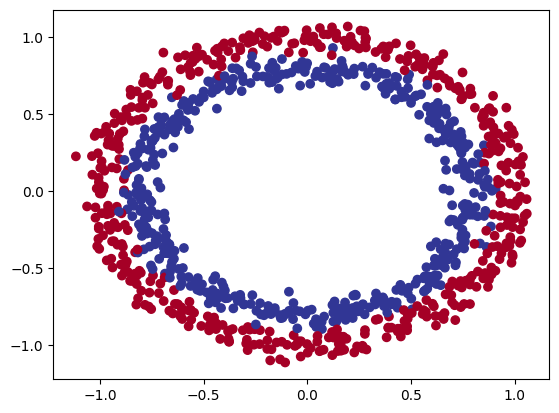

In [72]:
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [73]:
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

# Normalize the data using min-max scaling (0-1 range)
X_train_normalized = (X_train - X_train.min(axis=0)) / (X_train.max(axis=0) - X_train.min(axis=0))
X_test_normalized = (X_test - X_test.min(axis=0)) / (X_test.max(axis=0) - X_test.min(axis=0))

X_train_normalized.min(), X_train_normalized.max()

(np.float64(0.0), np.float64(1.0))

### **Find the Ideal Learning Rate**

#### **Ideal Learning Rate for Raw Data**

In [74]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch/20))

history = model.fit(X_train, y_train, 
                    epochs=100,
                    callbacks=[lr_callback])  



Epoch 1/100


I0000 00:00:1781673947.476939   84027 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_124166__.8


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4800 - loss: 0.6942 - learning_rate: 1.0000e-05
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4787 - loss: 0.6941 - learning_rate: 1.1220e-05
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4787 - loss: 0.6940 - learning_rate: 1.2589e-05
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4800 - loss: 0.6939 - learning_rate: 1.4125e-05
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4825 - loss: 0.6938 - learning_rate: 1.5849e-05
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4850 - loss: 0.6936 - learning_rate: 1.7783e-05
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4850 - loss: 0.6935 - learning_rate: 1.9953e-05
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4825 - loss: 0.6933 - learning_rate: 2.2387e-05
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4800 - loss: 0.6931 - learning_rate: 2.5119

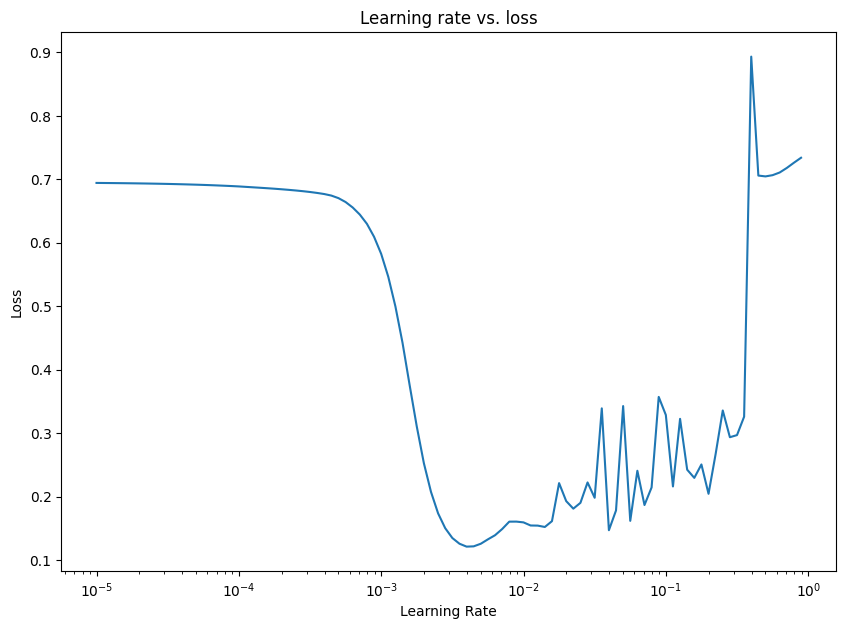

In [75]:
lrs = 1e-5 * (10 ** (np.arange(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

as per the graph above, somewhere around ```learning_rate = 0.00115``` is the safest option.

#### **Ideal Learning Rate for Normalized Data**

In [76]:
tf.random.set_seed(42)

model_normalized = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_normalized.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch/20))

history_normalized = model_normalized.fit(X_train_normalized, y_train, 
                    epochs=100,
                    callbacks=[lr_callback])  

Epoch 1/100


I0000 00:00:1781673971.031985   84026 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_137317__.8


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5025 - loss: 0.6925 - learning_rate: 1.0000e-05
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4988 - loss: 0.6924 - learning_rate: 1.1220e-05
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5025 - loss: 0.6923 - learning_rate: 1.2589e-05
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5038 - loss: 0.6922 - learning_rate: 1.4125e-05
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5050 - loss: 0.6921 - learning_rate: 1.5849e-05
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5038 - loss: 0.6921 - learning_rate: 1.7783e-05
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5038 - loss: 0.6920 - learning_rate: 1.9953e-05
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5088 - loss: 0.6919 - learning_rate: 2.2387e-05
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5088 - loss: 0.6918 - learning_rate: 2.5119

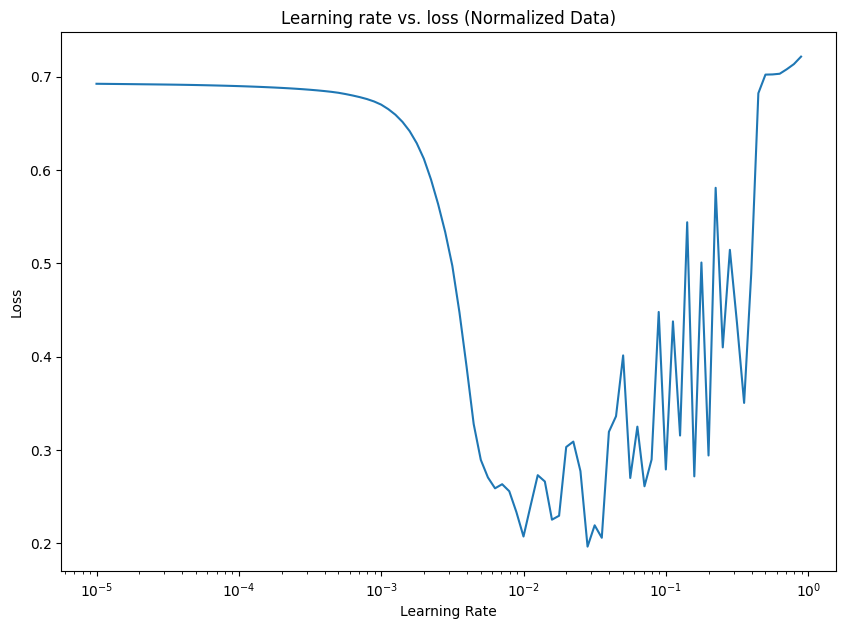

In [77]:
lrs = 1e-5 * (10 ** (np.arange(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_normalized.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss (Normalized Data)");

as per the graph above, somewhere around ```learning_rate = 0.015``` is the safest option for normalized data.

### **Create Model with Optimal Learning Rate**

#### **Model Trained on Raw Data**

In [80]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.00115),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, 
                    epochs=20,
                    validation_split=0.2)

Epoch 1/20


I0000 00:00:1781674742.636436   84024 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_158689__.8


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5188 - loss: 0.6873 - val_accuracy: 0.4187 - val_loss: 0.6989
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5188 - loss: 0.6826 - val_accuracy: 0.4187 - val_loss: 0.6984
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5188 - loss: 0.6792 - val_accuracy: 0.4187 - val_loss: 0.6977
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5188 - loss: 0.6756 - val_accuracy: 0.4187 - val_loss: 0.6959
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5203 - loss: 0.6717 - val_accuracy: 0.4250 - val_loss: 0.6925
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5406 - loss: 0.6675 - val_accuracy: 0.4625 - val_loss: 0.6889
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5578 - loss: 0.6628 - val_accuracy: 0.4812 - val_loss: 0.6840
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5984 - loss: 0.6571 - val_accuracy: 0.4938 - val_loss: 0.

#### **Model Trained on Normalized Data**

In [90]:
tf.random.set_seed(42)

model_normalized = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_normalized.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.015),
              metrics=['accuracy'])

history_normalized = model_normalized.fit(X_train_normalized, y_train, 
                    epochs=20,
                    validation_split=0.2)

Epoch 1/20


I0000 00:00:1781675209.977221   84028 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_199809__.8


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5172 - loss: 0.6959 - val_accuracy: 0.6313 - val_loss: 0.6766
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5531 - loss: 0.6844 - val_accuracy: 0.6062 - val_loss: 0.6682
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5734 - loss: 0.6754 - val_accuracy: 0.6250 - val_loss: 0.6480
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5969 - loss: 0.6627 - val_accuracy: 0.7563 - val_loss: 0.6195
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6422 - loss: 0.6453 - val_accuracy: 0.7812 - val_loss: 0.5822
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6656 - loss: 0.6177 - val_accuracy: 0.7750 - val_loss: 0.5298
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6984 - loss: 0.5779 - val_accuracy: 0.8687 - val_loss: 0.4776
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7828 - loss: 0.5135 - val_accuracy: 0.9250 - val_loss: 0.

### **Display Results**

In [91]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    x_input = np.c_[xx.ravel(), yy.ravel()]
    
    y_pred = model.predict(x_input)
    
    if model.output_shape[-1] > 1: 
        print("doing multiclass classification...")
        
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print('doing binary classification...')
        y_pred = np.round(np.max(y_pred, axis=1)).reshape(xx.shape)
        
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

def plot_confusion_matrix(cm, title):
    figsize = (8, 8)
    
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    n_classes = cm.shape[0]
    
    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)
    
    labels = np.arange(n_classes)
    
    ax.set(
        title=title,
        xlabel="Predicted Label",
        ylabel="True Label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels
    )
    
    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()
    
    threshold = (cm.max() + cm.min()) / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)",
            horizontalalignment="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=12
        )
    
    plt.show()

#### **Accuracy / Loss Graph**

Text(0.5, 1.0, 'Normalized Data Model Training')

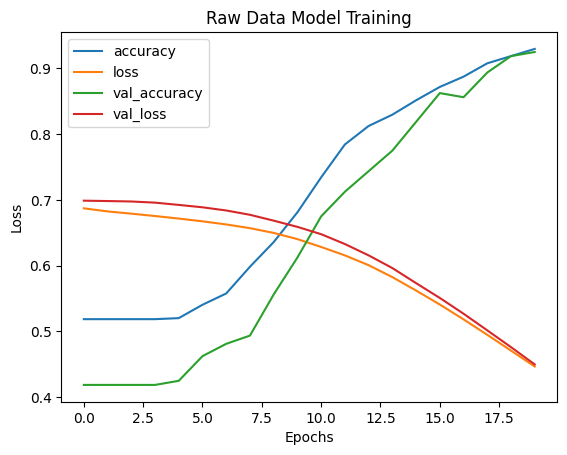

<Figure size 640x480 with 0 Axes>

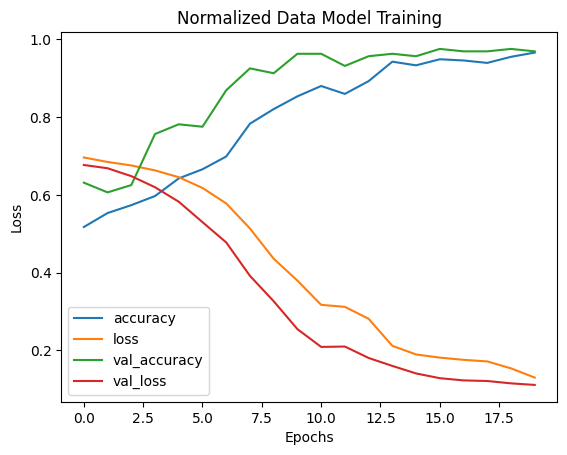

In [92]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')
mpl.pyplot.title('Raw Data Model Training')
plt.figure()
pd.DataFrame(history_normalized.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')
mpl.pyplot.title('Normalized Data Model Training')

#### **Normalized vs Raw Training Sets**

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
doing binary classification...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
doing binary classification...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
doing binary classification...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classification...


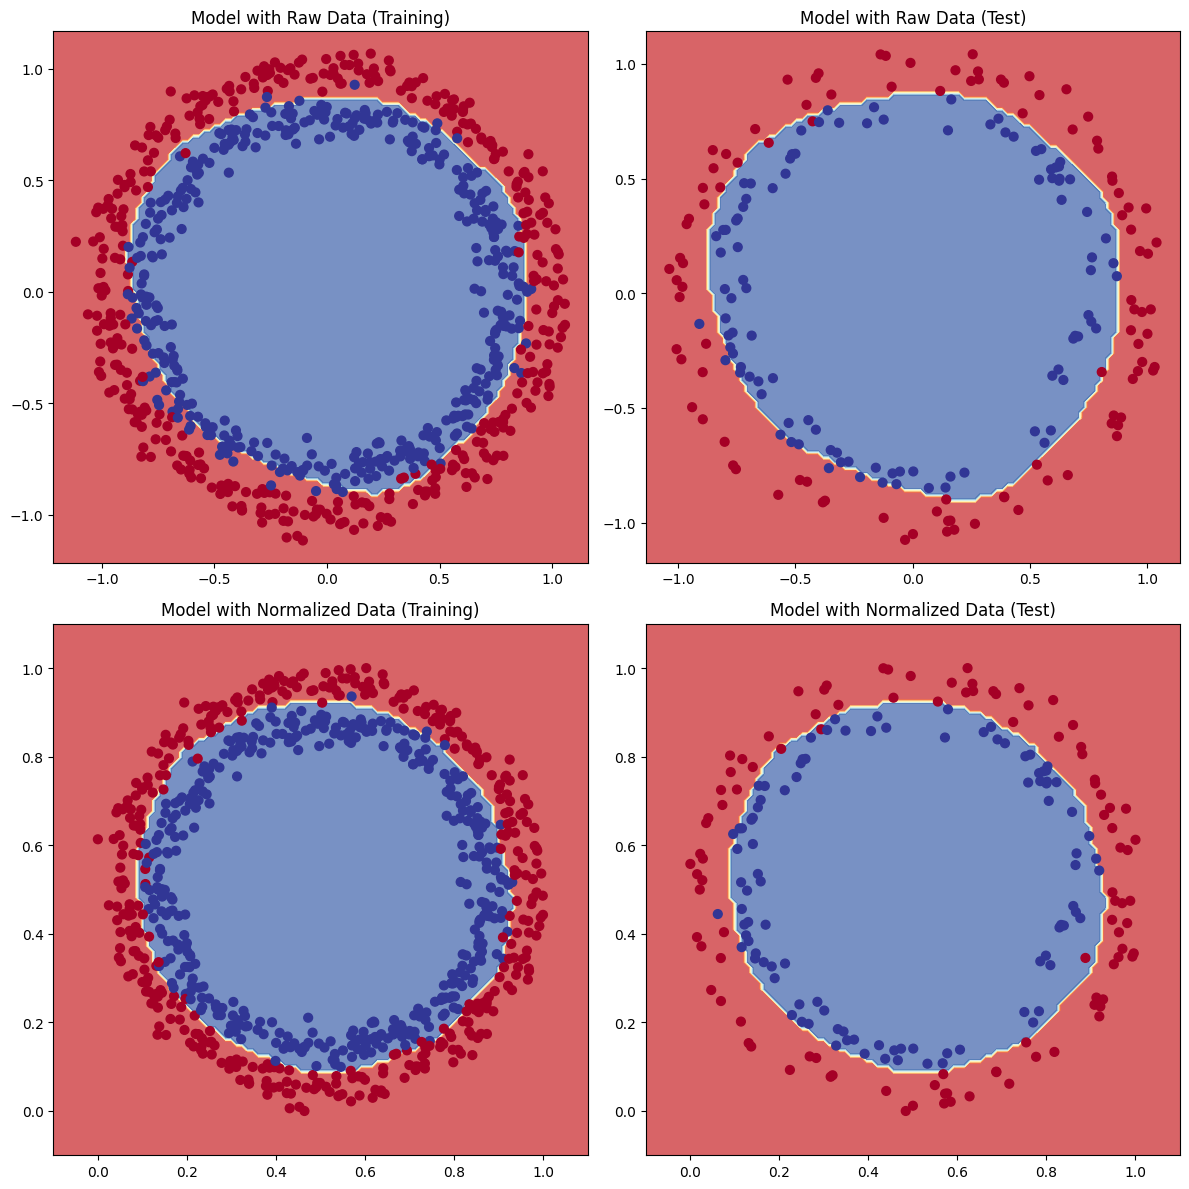

In [93]:
plt.figure(figsize=(12, 12))

plots = [
    ('Model with Raw Data (Training)', model, X_train, y_train),
    ('Model with Raw Data (Test)', model, X_test, y_test),
    ('Model with Normalized Data (Training)', model_normalized, X_train_normalized, y_train),
    ('Model with Normalized Data (Test)', model_normalized, X_test_normalized, y_test)
]

for i, (title, selected_model, img_data, labels) in enumerate(plots):
    plt.subplot(2, 2, i + 1)   # create/select subplot first
    plt.title(title)           # then set title on that subplot

    plot_decision_boundary(
        selected_model,
        img_data,
        labels
    )

plt.tight_layout()

#### **Confusion Matrices Comparison**

In [94]:
# Model w/ Raw data 
y_preds_raw = model.predict(X_test)
cm_raw = confusion_matrix(y_test, tf.round(y_preds_raw))
print("Raw Data Model Confusion Matrix:")
print(cm_raw)

# Model w/ Normalized data 
y_preds_normalized = model_normalized.predict(X_test_normalized)
cm_normalized = confusion_matrix(y_test, tf.round(y_preds_normalized))
print("\nNormalized Data Model Confusion Matrix:")
print(cm_normalized)

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Raw Data Model Confusion Matrix:
[[98  3]
 [ 7 92]]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

Normalized Data Model Confusion Matrix:
[[98  3]
 [ 3 96]]


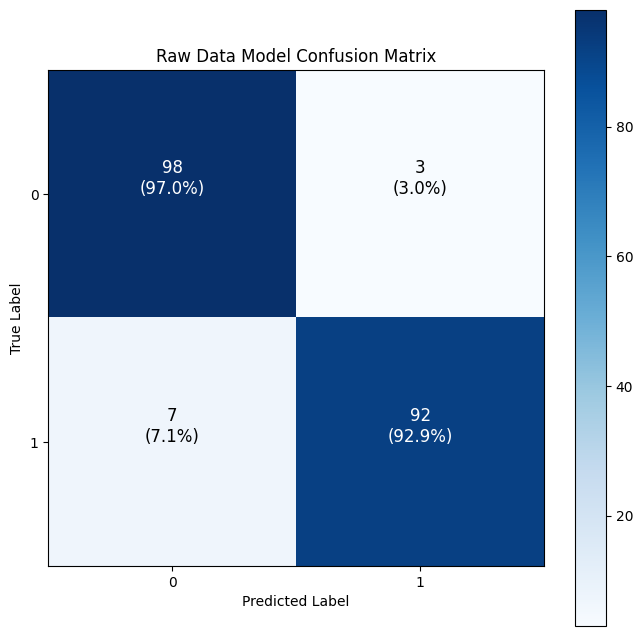

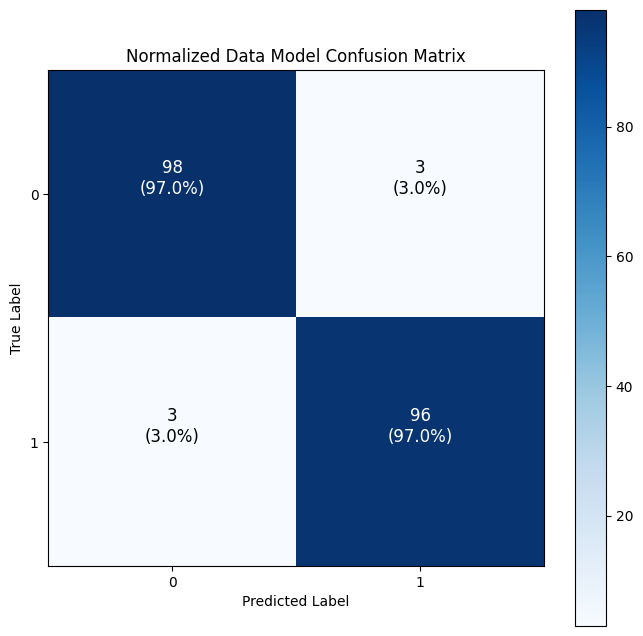

In [95]:
# Raw Data Model
plot_confusion_matrix(
    cm_raw,
    title="Raw Data Model Confusion Matrix"
)
# Normalized Data Model
plot_confusion_matrix(
    cm_normalized,
    title="Normalized Data Model Confusion Matrix"
)